# CE310 Class 05 

_Building a Register-based GP system from scratch_

This notebook shows the steps needed to create a GP system where programs are linear sequences of instructions which simply use two registers, ```R1``` and ```R2```, as sources of arguments for calculations and as places where to store results (like the assembly code for your CPU). Systems of this type are called _machine-code or register-based GP systems_.

_Conceptually_, instructions will have the form: 

```MUL R1 R2 -> R1```

which means: "multiply the values stored in ```R1``` and ```R2```, storing the result in ```R1```"

Like in real CPU our registers will always be initialised to 0. So, the following program:
```
# Before execution    R1=0, R2=0
LOAD 1 -> R1    # Now R1=1, R2=0
LOAD 1 -> R2    # Now R1=1, R2=1
ADD R1 R2 -> R1 # Now R1=2, R2=1
ADD R1 R2 -> R2 # Now R1=2, R2=3
```
will progressively modify the registers as shown in the comments. 

While _conceptually_ a program might look like the sequence of instructions above, before a CPU can execute assembly code, the code needs to be converted to a long list of integers. In other wors, from the point of a CPU a program is just a long sequence of integers. 

So, we will skip the logical representation. Instead **in our GP system we represent instructions as integers and programs as sequences of integers** and we will **define a simple CPU** to interpret them. 

**TASKS**

1. Complete and test a CPU for GP. Below is a code snippet that will get you off the ground:

```Python
# Simulator of register based CPU
# program = sequence of integers representing instructions
# x = external input to the program
def execute(program, x):
    # These are general purpose registers which can be both read and assigned values to by instructions
    R1 = 0
    R2 = 0

    for instruction in program:
        if instruction == 0: # NOP (no operation)
            pass
        elif instruction == 1: # MUL R1 R2 -> R1
            R1 = R1 * R2
        elif instruction == 2: # MUL R1 R2 -> R2
            R1 = R1 * R2
        elif ...
            
    # After program execution we return the value in R1
    return R1
```
Hint: add more instructions thinking about what type of information the CPU might need to use (external input? contants?) and what other other instructions might be useful.

Test the code using short lists of integers, e.g., ```execute([1,0,4,7], x)```, to make sure it behaves as expected.

2. Assuming programs will all be of the same length, say ```L=20```, create an initialisation algorithm that creates random programs. Use the following code ```matplotlib``` code to see what the programs represent:
```Python
plt.figure(figsize=(4,4))
# Let us run the program for different values of the input and plot the results
xs = range(-10,11)
ys =[execute(rand_prog, x) for x in xs]
plt.plot(xs, ys)
plt.grid()
plt.show()
```
Try say 10 times, to see if the behaviour/plot changes. If it does not, there may be a problem with your simulator.

3. Design a fitness function, which runs the  program with external input ```x=0```, and favours programs the output of which is close to 5. Invoke the function with multiple random programs created with your initialisation algorithm, to see if fitness varies. Hint: you may need to do some transformation of the fitess so that high values mean that the program output is close to 5 and low values mean that the program output is not close to 5.
  
Test the fitness function with very simple handcrafted programs where you know what the output is and so you know which program should have higher fitness.

4. Like we previously did for the bin-packing and other problems, use random search to see if you can evolve a perfect solution to the problem.

5. Now define a fitness function that will test programs with multiple values of ```x``` and will compare the outputs to the outputs produced by this function:
```Python
def target_function(x):
    return x**4 + x**3 + x**2 + x + 3
```
Hint: the plotting code shown above already does part of the job! 

6. Try random search again, but with this time with the fitness function just defined. Plot the behaviour of the best programs. Notice that *this is a form of symbolic regression*.

7. Time to add evolution. Implement a mutation operator that would make small random changes to programs, without generating any invalid opcodes (i.e., integers that the CPU does not understand). Test it thoroughly, but passing valid programs and checking that the children produced are still valid (and not too different from the parent program).

8. Implement a (1+1) Evolution Strategy, that is 1 (initially random) parent gets mutated producing 1 offspring, the fitness of the two is compared, the best becomes the parent, and the cycle continues. Run the (1+1) ES for the same number of steps as the random search used in Task 5 above, to see whether solutions to the symbolic regression problem look better.

9. Grap a crossover operator and selection method from previous labs (e.g., one point crossover and tournament selection will do), create a randomly initialised population, implement the main loop (e.g., grab it from a steady state GA). This will be a fully complete register-based GP system.

Rerun the symbolic regression, and see if a population and crossover provide additional benefits over random search and the (1+1) ES. 


### Simulating a simple CPU (with just 2 registers and a handfull of instructions)

Random program:
[1, 6, 5, 7, 1, 12, 4, 3, 15, 9]


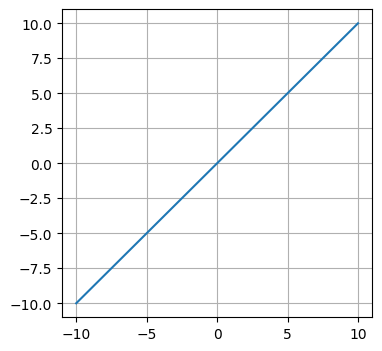

Random program:
[15, 11, 6, 11, 7, 9, 15, 13, 10, 13]


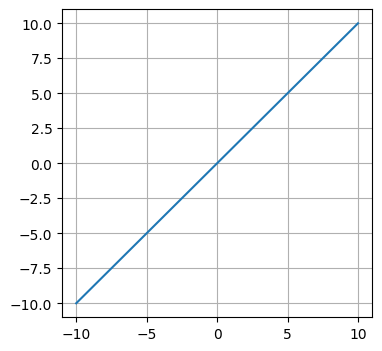

Random program:
[1, 8, 14, 0, 1, 1, 5, 10, 15, 11]


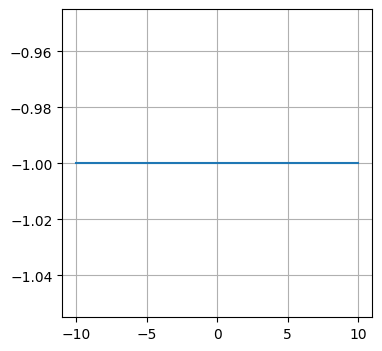

Random program:
[15, 5, 9, 4, 15, 9, 8, 15, 7, 12]


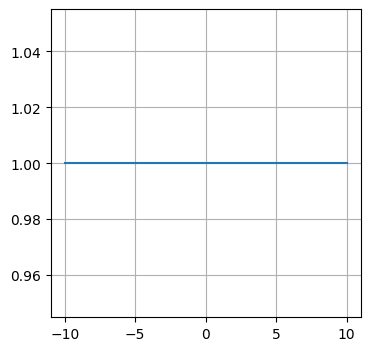

Random program:
[0, 2, 3, 13, 9, 6, 0, 10, 0, 13]


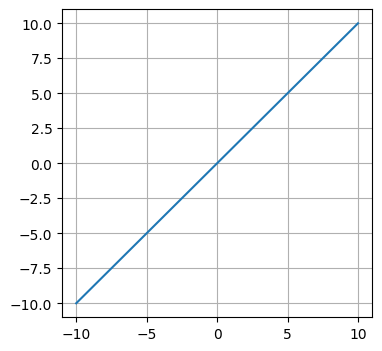

Random program:
[5, 10, 14, 8, 15, 7, 9, 13, 14, 2]


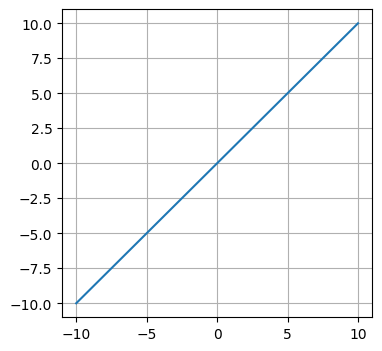

Random program:
[6, 3, 0, 14, 0, 12, 9, 1, 13, 12]


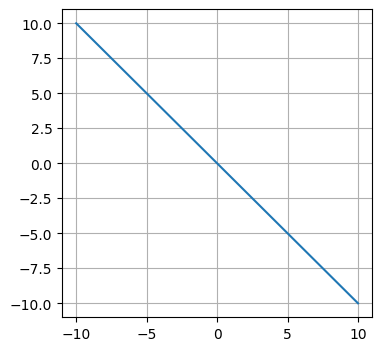

Random program:
[8, 12, 12, 3, 6, 13, 1, 5, 0, 1]


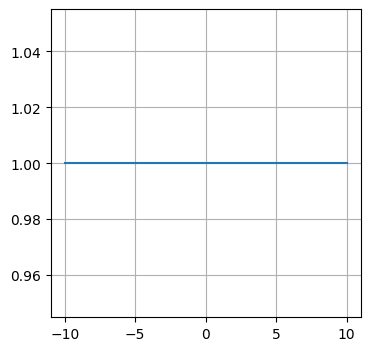

Random program:
[5, 0, 13, 11, 1, 7, 15, 10, 3, 14]


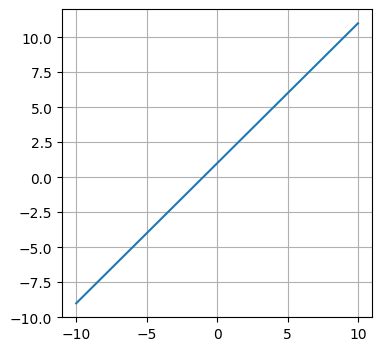

Random program:
[11, 6, 14, 7, 1, 0, 2, 14, 1, 8]


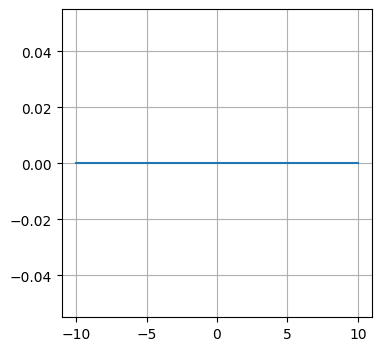

In [1]:
# Tasks 1 and 2
from random import choices
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Simulator of register based CPU
# program = sequence of integers representing instructions
# x = external input to the program
def execute(program, x):
    # These are general purpose registers which can be both read and assigned values to by instructions
    R1 = 0
    R2 = 0

    for instruction in program:
        if instruction == 0: # NOP (no operation)
            pass
        elif instruction == 1: # MUL R1 R2 -> R1
            R1 = R1 * R2
        elif instruction == 2: # MUL R1 R2 -> R2
            R2 = R1 * R2
        elif instruction == 3: # ADD R1 R2 -> R1
            R1 = R1 + R2
        elif instruction == 4: # ADD R1 R2 -> R2
            R2 = R1 + R2
        elif instruction == 5: # -R1 -> R1
            R1 = -R1
        elif instruction == 6: # -R2 -> R2
            R2 = -R2
        elif instruction == 7: # 1 -> R1
            R1 = 1
        elif instruction == 8: # 1 -> R2
            R2 = 1
        elif instruction == 9: # x -> R1
            R1 = x
        elif instruction == 10: # x -> R2
            R2 = x
        elif instruction == 11: # -1 -> R1
            R1 = -1
        elif instruction == 12: # -1 -> R2
            R2 = -1
        else: # instructions > 12 all map to NOP
            pass
            
    # After program execution we return the value in R1
    return R1


primitives = range(16)

# Once we know the primitives we can just generate random programs
# by selecting them at random
def generate_random_program(length=10):
    return choices(primitives, k = length)


# Let us generate a few random programs 
for _ in range(10):
    rand_prog = generate_random_program()
    
    print('Random program:')
    print(rand_prog)
    
    plt.figure(figsize=(4,4))
    # Let us run the program for different values of the input and plot the results
    xs = range(-10,11)
    ys =[execute(rand_prog, x) for x in xs]
    plt.plot(xs, ys)
    plt.grid()
    plt.show()

## Let us now try random search to explore the space of register-based linear programs
Target function: produce 5 when program run with x=0

best_fitness 0
best program
[0, 11, 7, 4, 14, 3, 1, 8, 2, 1, 5, 13, 9, 7, 14, 3, 12, 4, 3, 6]


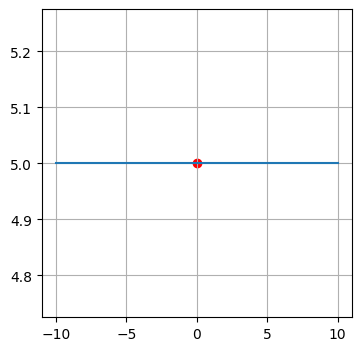

In [2]:
# Tasks 3 and 4
from time import sleep
import numpy as np


def fitness_function( program ):
    y = execute( program, 0)
    target = 5
    abs_diff = abs(y - target)
    return abs_diff

# Parameters
prog_len = 20
max_tries = 100_000

# We use RANDOM SEARCH HERE

# Initilise the search
parent_prog = generate_random_program(prog_len)
parent_fitness = fitness_function( parent_prog )


# Main loop
for generation in range(1, max_tries + 1):
    child_prog = generate_random_program(prog_len) # Note child = RANDOM program!
    child_fitness = fitness_function( child_prog )
    if child_fitness < parent_fitness:
        parent_fitness = child_fitness
        parent_prog = child_prog
        
print('best_fitness', parent_fitness)
print('best program')
print(parent_prog)

# Let us plot the behaviour of the program also for x different from 0 
# just to see how our search solved the problem
plt.figure(figsize=(4,4))
# Let us run the program for different values of the input and plot the results
xs = range(-10,11)
ys =[execute(parent_prog, x) for x in xs]
plt.plot(xs, ys)
plt.scatter(0,5,color='red')
plt.grid()
plt.show()


## Let us now try random search to explore the space of register-based linear programs
The target now is to fit the function ```x**4 + x**3 + x**2 + x + 3```


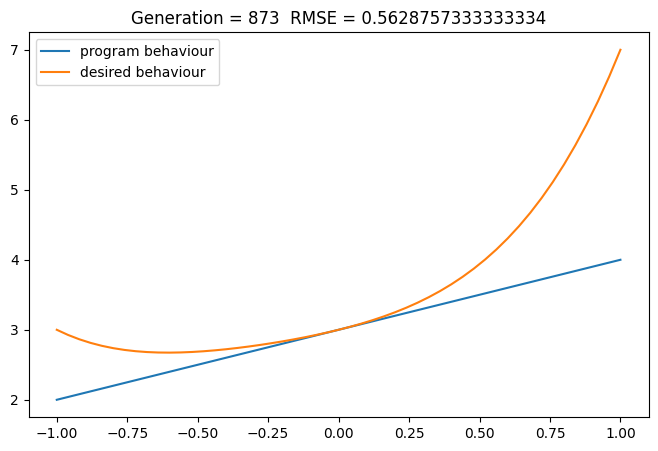

best program
[8, 7, 9, 0, 8, 3, 0, 3, 0, 15, 3, 4, 13, 12, 6, 13, 6, 10, 8, 10]


In [3]:
from time import sleep
import numpy as np

# Code needed to make sure we keep replotting in one figure per tab 
# rather than generating many new figures  
%matplotlib inline
fig = plt.figure(figsize=(8,5))
axes = fig.add_subplot(111)
hfig = display(fig, display_id=True)

def target_function(x):
    return x**4 + x**3 + x**2 + x + 3

def sum_abs_diffs(ys_true, ys_pred):
    return np.mean([abs(y_true - y_pred) for (y_true, y_pred) in zip(ys_true, ys_pred)])

def fitness_function( program, xs, generation, plot = True ):
    ys = [execute( program, x) for x in xs]
    targets = [target_function(x)  for x in xs]
    RMSE = sum_abs_diffs(ys, targets)
    if plot:
        axes.cla()
        axes.plot(xs, ys, label = 'program behaviour')
        axes.plot(xs, targets, label = 'desired behaviour')
        axes.legend()
        axes.set_title(f'Generation = {generation}  RMSE = {RMSE}')
        fig.canvas.draw()
        hfig.update(fig)
    return RMSE

# Parameters
prog_len = 20
max_tries = 100_000
xs = np.linspace(-1,1,51)

# We use RANDOM SEARCH HERE

# Initilise the search
parent_prog = generate_random_program(prog_len)
parent_fitness = fitness_function( parent_prog, xs, 0 )


# Main loop
for generation in range(1, max_tries + 1):
    child_prog = generate_random_program(prog_len) # Note child = RANDOM program!
    child_fitness = fitness_function( child_prog, xs, generation, plot=False )
    if child_fitness < parent_fitness:
        parent_fitness = child_fitness
        parent_prog = child_prog
        fitness_function( parent_prog, xs, generation, plot=True)

print('best program')
print(parent_prog)

plt.close(fig)
clear_output(wait=True)


## Let us define a mutation operation and then use a (1+1) Evolutionary Algorithm to evolve programs

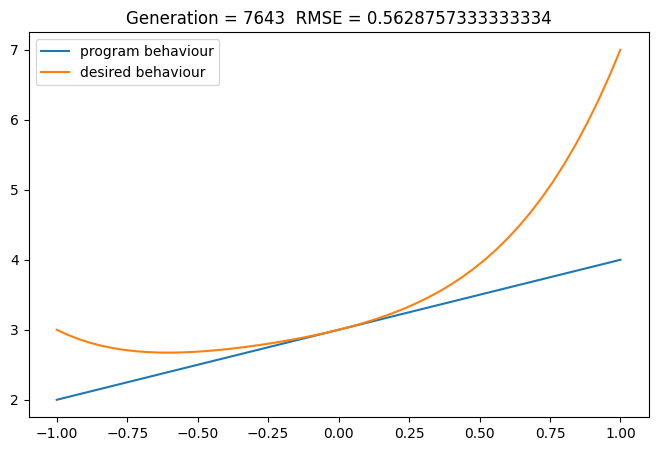

best program
[7, 9, 6, 13, 7, 3, 10, 11, 15, 8, 10, 13, 12, 9, 14, 8, 14, 11, 7, 14, 4, 11, 11, 11, 5, 3, 10, 3, 12, 0]


In [4]:
# Task 7 and 8
from random import random

# Usual plotting code
%matplotlib inline
fig = plt.figure(figsize=(8,5))
axes = fig.add_subplot(111)
hfig = display(fig, display_id=True)

# We now define a mutation operator
# It generates a random program and we replace 10% of the instructions
# of the parent program with corresponding instructions from the random program
# to generate the offspring
def mutate(parent):
    mutation_rate = 1 / len(parent)
    offspring = []
    for instruction in parent:
        if random() < mutation_rate: 
            offspring.append(choices(primitives,k=1)[0])
        else:
            offspring.append(instruction)
    return offspring

# Parameters
prog_len = 30
max_tries = 100_000
xs = np.linspace(-1,1,51)

# We use a (1+1) EA HERE

# Initilise the search
parent_prog = generate_random_program(prog_len)
parent_fitness = fitness_function( parent_prog, xs, 0 )

# Main loop
for generation in range(1, max_tries + 1):
    child_prog = mutate(parent_prog)  ## NOTE: THIS IS A PROPER OFFSPRING OF THE PARENT
    child_fitness = fitness_function( child_prog, xs, generation, plot=False )
    if child_fitness < parent_fitness:
        parent_fitness = child_fitness
        parent_prog = child_prog
        fitness_function( parent_prog, xs, generation, plot=True)

print('best program')
print(parent_prog)

plt.close(fig)
clear_output(wait=True)


## Adding a population, selection and crossover

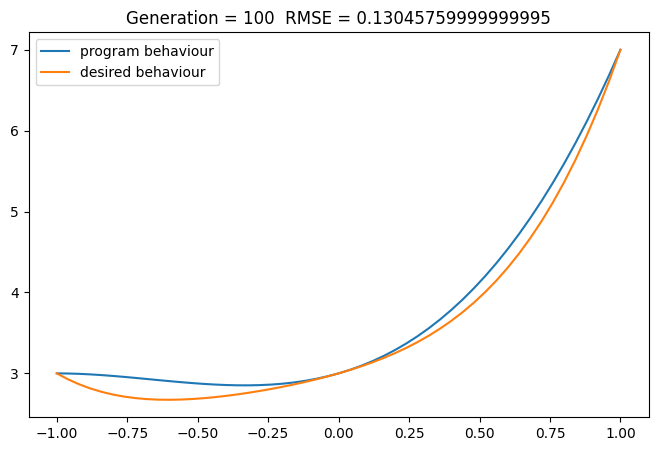

best program
[14  6  9 10  6  4 10  7  3 11  6  5 11 12  9  6  3 10 15  2  0  1  4  8
  3  3  1  3 13 14]


In [5]:
# Task 9
from random import randint

# Usual plotting code
%matplotlib inline
fig = plt.figure(figsize=(8,5))
axes = fig.add_subplot(111)
hfig = display(fig, display_id=True)


pop_size = 500
generations = 100
prog_len = 30

# Initilise the population array
population = np.array([generate_random_program(prog_len) for _ in range(pop_size)])

# Initilise fitness array
fitnesses = np.array([fitness_function( prog, xs, 0, False ) for prog in population])

best_fitness = fitnesses[np.argmin(fitnesses)]
best_prog = population[np.argmin(fitnesses)]
fitness_function(best_prog, xs, 'initial', plot = True)

# Find the fittest half of the population and return it together with the fitness
def truncation_selection( population, fitnesses ):
    selected_individuals = np.argsort(fitnesses)[:pop_size//2]
    return population[selected_individuals], fitnesses[selected_individuals]

# Perform one point crossover and mutate the offspring for added diversity
def crossover_and_mutate( p1, p2 ):
    xo_pt = randint(1, prog_len-1 )
    offspring = np.concatenate((p1[:xo_pt],p2[xo_pt:]))
    return mutate(offspring)

# Pair up the individuals in the population for crossover
def prepare_for_xo(population):
    return population.reshape((population.shape[0]//2, 2, prog_len))

for generation in range(1, generations + 1):
    # Apply selection
    selected_population, selected_fitnesses =  truncation_selection(population, fitnesses)

    # Generate a bunch of offpsring programs via crossover and mutation of the individuals selected
    offspring = np.array([crossover_and_mutate(p1, p2) for p1, p2 in prepare_for_xo(selected_population)]) 
    offspring_fitnesses = np.array([fitness_function( prog, xs, 0, False ) for prog in offspring])
    population = np.concatenate((selected_population, offspring))
    fitnesses = np.concatenate((selected_fitnesses, offspring_fitnesses))

    args = np.argsort(fitnesses)
    if min(fitnesses) < best_fitness:
        best_fitness = fitnesses[np.argmin(fitnesses)]
        best_prog = population[np.argmin(fitnesses)]
        fitness_function(best_prog, xs, generation + 1, plot = True)

print('best program')
print(best_prog)
fitness_function(best_prog, xs, generation, plot=True)

plt.close(fig)
clear_output(wait=True)


### Understading the evolved programs

In [7]:
import sympy as sp


def execute_symbolic(program):
    # Define symbolic variables
    x = sp.Symbol('x')  
    R1 = 0
    R2 = 0 

    # NOTE THE FOLLOWING CODE IS EXACTLY (!) THE SAME AS IN execute()
    for instruction in program:
        if instruction == 0: # NOP (no operation)
            pass
        elif instruction == 1: # MUL R1 R2 -> R1
            R1 = R1 * R2
        elif instruction == 2: # MUL R1 R2 -> R2
            R2 = R1 * R2
        elif instruction == 3: # ADD R1 R2 -> R1
            R1 = R1 + R2
        elif instruction == 4: # ADD R1 R2 -> R2
            R2 = R1 + R2
        elif instruction == 5: # -R1 -> R1
            R1 = -R1
        elif instruction == 6: # -R2 -> R2
            R2 = -R2
        elif instruction == 7: # 1 -> R1
            R1 = 1
        elif instruction == 8: # 1 -> R2
            R2 = 1
        elif instruction == 9: # x -> R1
            R1 = x
        elif instruction == 10: # x -> R2
            R2 = x
        elif instruction == 11: # -1 -> R1
            R1 = -1
        elif instruction == 12: # -1 -> R2
            R2 = -1
        else: # instructions > 12 all map to NOP
            pass
            
    # After program execution we return the value in R1
    return R1

def target_function_symbolic():
    x = sp.Symbol('x')  
    return target_function(x)

program = execute_symbolic(best_prog)     
print("program:", program, "-->", program.expand().simplify())
print("Target function:", target_function_symbolic())

program: x*(x + 1)**2 + 3 --> x**3 + 2*x**2 + x + 3
Target function: x**4 + x**3 + x**2 + x + 3
